In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.gridspec as gridspec
import cartopy
import os

In [42]:
metadata_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/metadata/40_50yr_sites.csv')
metadata_df.set_index('Number',inplace=True)

# load flow data into dataframe
flow_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/flows/daily/50yrs/full_records.csv')
flow_df.Date = pd.to_datetime(flow_df.Date)
flow_df.set_index('Date', inplace=True)

# define alpha and numeric season order
seasons_a = ['Winter','Spring','Summer','Autumn']
seasons_n = [6,9,12,3]

colors = ['r','b',"#000000", "#FFFF00", "#1CE6FF", "#FF34FF", "#FF4A46", "#008941", "#006FA6", "#A30059",
"#FFDBE5", "#7A4900", "#0000A6", "#63FFAC", "#B79762", "#004D43", "#8FB0FF", "#997D87",
"#5A0007", "#809693", "#FEFFE6", "#1B4400", "#4FC601", "#3B5DFF", "#4A3B53", "#FF2F80",
"#61615A", "#BA0900", "#6B7900", "#00C2A0", "#FFAA92", "#FF90C9", "#B903AA", "#D16100"]

In [3]:
fp = '/nesi/project/niwa00015/queenle/data/arcgis/'
file = 'NESTCAT_v2_NZTM.shp'
catchment_data = gpd.read_file(fp+file)
catchment_data = catchment_data.to_crs("EPSG:4326")

catchments_df = catchment_data.loc[catchment_data['SITE'].isin(flow_df.columns)]

subset_meta = metadata_df.loc[[int(s) for s in flow_df.columns]]
subset_meta.sort_values('gauge_lat', ascending = False, inplace=True)
subset_meta['number_label'] = np.arange(1,len(subset_meta)+1)
subset_meta['number_copy'] = subset_meta.index.values.tolist()

meta_df = gpd.GeoDataFrame(subset_meta, 
                                  geometry=gpd.points_from_xy(x=subset_meta.gauge_lon, y=subset_meta.gauge_lat),
                          crs='EPSG:4326')

In [4]:
winter = {1: [1316, 3506, 46618, 46651, 4901, 9301],
          2: [1043427, 1043428, 1043461, 1043466, 15408, 15410, 16501, 32503, 9205,
                       21412, 21801, 23104, 29224, 29808, 33117, 33316, 33347, 36001, 43472],
          3: [52916, 57009, 60114, 64602, 65104, 71116, 71120, 71123, 71129, 
              71132, 71135, 75232, 75288, 75292, 77505, 78625, 79704, 79713, 93203, 95101],
          4: [60104, 62105, 64610, 68001, 68806, 69621, 73501, 62103], 
         }

winter_names = {1: 'Northland',2: 'Central North Island',3:'West South Island',4:'East South Island'}
                   
summer = {1: [1043427, 1043428, 1043461, 1316, 15410, 16501, 21412, 21801, 23104, 32503, 
              33316, 3506, 43472, 46618, 46651, 4901, 9205, 9301, 15408],
          2: [1043466, 29224, 29808, 33117, 33347, 36001],
          3: [60114, 64602, 65104, 71116, 71120, 71123, 71129, 71132, 71135, 75232, 
              75288, 75292, 77505, 78625, 79704, 79713, 93203, 95101,52916],
          4: [57009, 60104, 62103, 62105, 64610, 68001, 68806, 69621,73501]
          }

summer_names = {1:'Northland', 2:'South North Island', 3:'West South Island', 4:'East South Island'}

autumn = {1: [1043427, 1043428, 1043461, 1043466, 1316, 15408, 15410, 16501, 21412, 21801, 
              23104, 32503, 33316, 33347, 3506, 43472, 46618, 46651, 4901, 9205, 9301],
          2: [29224, 29808, 33117, 36001, 52916, 57009, 60104, 60114, 62103, 62105, 64602, 
              64610, 65104, 68001, 68806, 69621, 71116, 71120, 71123, 71129, 71132, 71135, 
              73501, 75232, 75288, 75292, 77505, 78625, 79704, 79713, 93203, 95101]
         }

autumn_names = {1:'North', 2:'South'}

spring = {1: [1043427, 1043428, 1316, 15408, 15410, 16501, 21412, 21801, 23104, 32503, 
              3506, 43472, 46618, 46651, 4901, 60104, 64610, 68001, 69621, 73501, 9205, 9301],
          2: [1043461, 1043466, 29224, 29808, 33117, 33316, 33347, 36001, 52916, 57009, 
              60114, 62103, 62105, 64602, 65104, 68806, 71116, 71120, 71123, 71129, 71132, 
              71135, 75232, 75288, 75292, 77505, 78625, 79704, 79713, 93203, 95101]
          }
spring_names = {1: 'East', 2: 'West'}


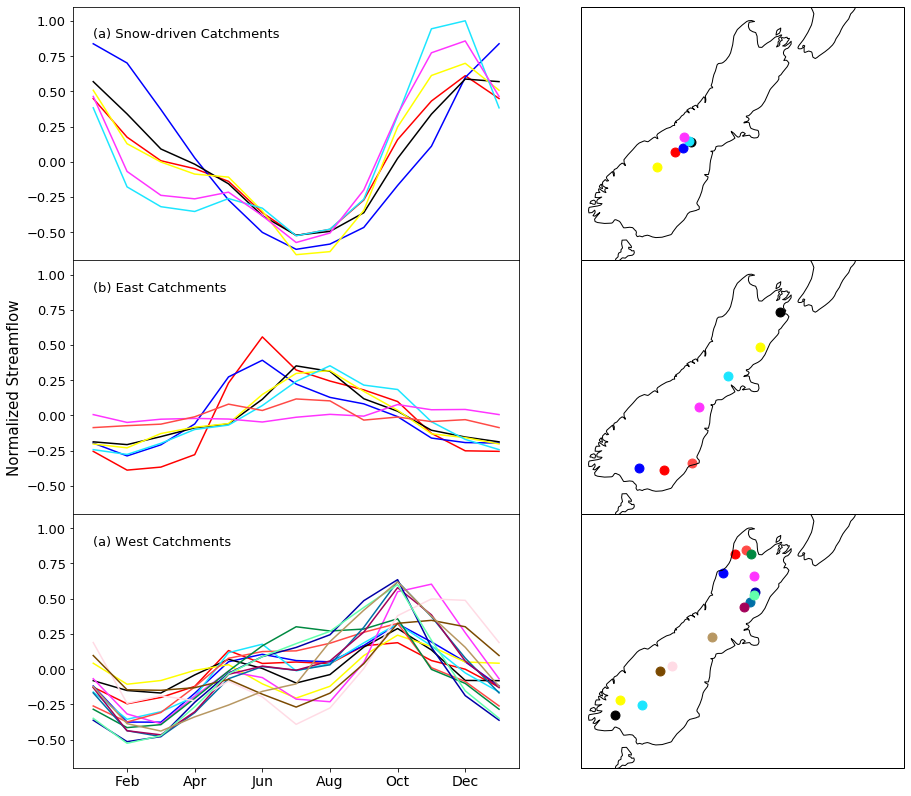

In [45]:
# Define the CartoPy CRS object.
crs = ccrs.Mercator()

# This can be converted into a `proj4` string/dict compatible with GeoPandas
crs_proj4 = crs.proj4_init
meta_df_ae = meta_df.to_crs(crs_proj4)

fig = plt.figure(figsize=(16,14))#,constrained_layout=True)
spec = gridspec.GridSpec(ncols=2, nrows=3, wspace=0, hspace=0,figure=fig)

ax1 = fig.add_subplot(spec[0, 0])
ax2 = fig.add_subplot(spec[0, 1], projection=crs)
ax3 = fig.add_subplot(spec[1, 0])
ax4 = fig.add_subplot(spec[1, 1], projection=crs)
ax5 = fig.add_subplot(spec[2, 0])
ax6 = fig.add_subplot(spec[2, 1], projection=crs)

axs = [ax1,ax2,ax3,ax4,ax5,ax6]

anom = (flow_df - flow_df.mean()) / flow_df.std()

wc1 = ['71120','71123','71132','75292','71129','71135']
wc2 = ['75232','78625',
      '60104','64610', '68001', '69621','73501']
wc3 = ['95101','93203','79713','79704','77505','60114','52916','57009','64602','65104','71116','75288',
       '62103', '62105', '68806']
groups = [wc1,wc2,wc3] 

for i,group in enumerate(groups): 
    
    cluster_df = anom[[str(val) for val in group]]
    
    for j,site in enumerate(group):
        annual_cycle = cluster_df[site].groupby(cluster_df[site].index.month).mean()
        axs[i*2].plot(annual_cycle.index.values.tolist() + [13],annual_cycle.values.tolist() + [annual_cycle.values.tolist()[0]],c=colors[j],label=site + ': ' + str(metadata_df.loc[int(site)]['Name']))
        axs[i*2].set_ylim(-0.7,1.1)
        axs[i*2].set_yticks([-0.5+0.25*i for i in range(7)])

        lon = meta_df_ae.loc[int(site)].geometry.centroid.coords[0][0]
        lat = meta_df_ae.loc[int(site)].geometry.centroid.coords[0][1]

        axs[i*2+1].scatter(lon,lat,marker='o',s=80,c=colors[j])

    axs[i*2+1].coastlines(resolution='50m', color='black',linewidth=1)
    axs[i*2+1].set_xlim([18500000,19900000])
    axs[i*2+1].set_ylim([-5950000,-4850000])
        
axs[4].set_xticks([2,4,6,8,10,12],)
axs[4].set_xticklabels(['Feb','Apr','Jun','Aug','Oct','Dec'])
axs[0].tick_params(axis='y',labelsize=13)
axs[2].tick_params(axis='y',labelsize=13)
axs[4].tick_params(axis='y',labelsize=13)
axs[4].tick_params(axis='x',labelsize=14)

axs[2].set_ylabel('Normalized Streamflow',fontsize=15)
#axs[2].legend()

axs[0].text(1,.88,"(a) Snow-driven Catchments",fontsize=13)
axs[2].text(1,.88,"(b) East Catchments",fontsize=13)
axs[4].text(1,.88,"(a) West Catchments",fontsize=13)

plt.savefig('Figure5.png',dpi=300,bbox_inches='tight')


In [15]:
annual_cycle.values.tolist() + [annual_cycle.values.tolist()[0]]

[0.09667254470474189,
 -0.14636382384598773,
 -0.15004793207425882,
 -0.13150766631092664,
 -0.07301691413271215,
 -0.17768583713151606,
 -0.26913892813612644,
 -0.17037425450288846,
 0.03852011409883603,
 0.3251664883409055,
 0.34626854383814026,
 0.30087692394209103,
 0.09667254470474189]

['1043466', '15408']
['32503', '33316', '3506', '46618', '46651', '4901', '9205', '9301', '1043427', '1043428', '1043461', '1316', '15410', '16501', '21412', '21801', '23104', '36001', '43472']
['29224', '29808', '33117', '33347']


Text(0, 0.5, 'streamflow anomaly')

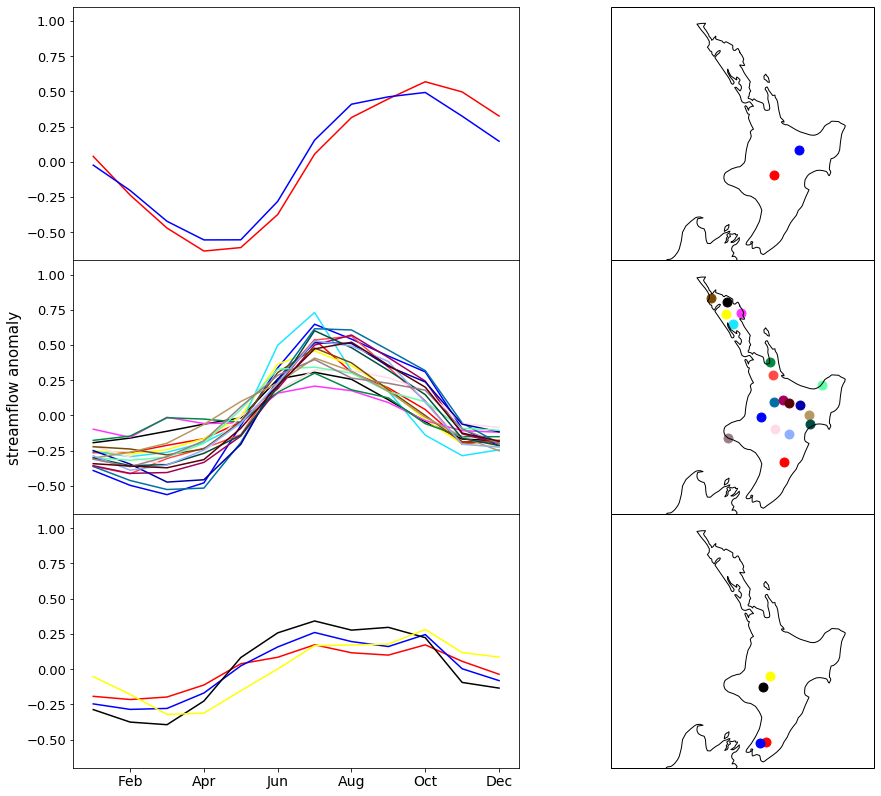

In [42]:
# Define the CartoPy CRS object.
crs = ccrs.Mercator()

# This can be converted into a `proj4` string/dict compatible with GeoPandas
crs_proj4 = crs.proj4_init
meta_df_ae = meta_df.to_crs(crs_proj4)

fig = plt.figure(figsize=(16,14))#,constrained_layout=True)
spec = gridspec.GridSpec(ncols=2, nrows=3, wspace=0, hspace=0,figure=fig)

ax1 = fig.add_subplot(spec[0, 0])
ax2 = fig.add_subplot(spec[0, 1], projection=crs)
ax3 = fig.add_subplot(spec[1, 0])
ax4 = fig.add_subplot(spec[1, 1], projection=crs)
ax5 = fig.add_subplot(spec[2, 0])
ax6 = fig.add_subplot(spec[2, 1], projection=crs)

axs = [ax1,ax2,ax3,ax4,ax5,ax6]

anom = (flow_df - flow_df.mean()) / flow_df.std()


ni1 = ['1043466','15408']
ni3 = ['29224', '29808', '33117', '33347']
ni2 = [ '32503', '33316', '3506', '46618', '46651','4901', '9205', '9301','1043427', '1043428', '1043461', 
        '1316', '15410', '16501', '21412', '21801', '23104', '36001', '43472']

groups = [ni1,ni2,ni3] 

for i,group in enumerate(groups): 
    
    print(group)
    
    cluster_df = anom[group]
    
    for j,site in enumerate(group):
        annual_cycle = cluster_df[site].groupby(cluster_df[site].index.month).mean()
        axs[i*2].plot(annual_cycle,c=colors[j])#,label=site + ': ' + str(metadata_df.loc[int(site)]['Name']))
        axs[i*2].set_ylim(-0.7,1.1)
        axs[i*2].set_yticks([-0.5+0.25*i for i in range(7)])

        lon = meta_df_ae.loc[int(site)].geometry.centroid.coords[0][0]
        lat = meta_df_ae.loc[int(site)].geometry.centroid.coords[0][1]

        axs[i*2+1].scatter(lon,lat,marker='o',s=80,c=colors[j])

    axs[i*2+1].coastlines(resolution='50m', color='black',linewidth=1)
    axs[i*2+1].set_xlim([18850000,20000000])
    axs[i*2+1].set_ylim([-5100000,-3990000])
        
axs[4].set_xticks([2,4,6,8,10,12],)
axs[4].set_xticklabels(['Feb','Apr','Jun','Aug','Oct','Dec'])
axs[0].tick_params(axis='y',labelsize=13)
axs[2].tick_params(axis='y',labelsize=13)
axs[4].tick_params(axis='y',labelsize=13)
axs[4].tick_params(axis='x',labelsize=14)

axs[2].set_ylabel('streamflow anomaly',fontsize=15)

#plt.savefig('Figure5.png',dpi=300,bbox_inches='tight')


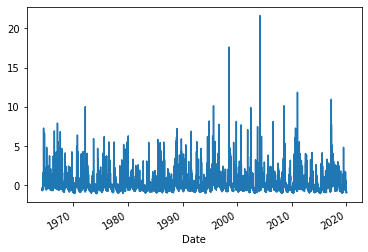

In [9]:
# Define the CartoPy CRS object.
crs = ccrs.Mercator()

# This can be converted into a `proj4` string/dict compatible with GeoPandas
crs_proj4 = crs.proj4_init
meta_df_ae = meta_df.to_crs(crs_proj4)

fig = plt.figure(figsize=(16,14))#,constrained_layout=True)
spec = gridspec.GridSpec(ncols=2, nrows=3, wspace=0, hspace=0,figure=fig)

ax1 = fig.add_subplot(spec[0, 0])
ax2 = fig.add_subplot(spec[0, 1], projection=crs)
ax3 = fig.add_subplot(spec[1, 0])
ax4 = fig.add_subplot(spec[1, 1], projection=crs)
ax5 = fig.add_subplot(spec[2, 0])
ax6 = fig.add_subplot(spec[2, 1], projection=crs)

axs = [ax1,ax2,ax3,ax4,ax5,ax6]

anom = (flow_df - flow_df.mean()) / flow_df.std()

wc1 = ['71120','71123','71132','75292','71129','71135']
#wc2 = ['75232','78625']
#wc3 = ['95101','93203','79713','79704','77505','60114','52916','57009','64602','65104','71116','75288']

groups = [wc1,wc1]#,wc2,wc3] 

for i,group in enumerate(groups): 
    
    cluster_df = anom[[str(val) for val in group]]
    
    for j,site in enumerate(group):
        annual_cycle = cluster_df[site].groupby(cluster_df[site].index.month).mean()
        axs[i*2].plot(annual_cycle,c=colors[j])#,label=site + ': ' + str(metadata_df.loc[int(site)]['Name']))
        axs[i*2].set_ylim(-0.7,1.1)
        axs[i*2].set_yticks([-0.5+0.25*i for i in range(7)])

        lon = meta_df_ae.loc[int(site)].geometry.centroid.coords[0][0]
        lat = meta_df_ae.loc[int(site)].geometry.centroid.coords[0][1]

        axs[i*2+1].scatter(lon,lat,marker='o',s=80,c=colors[j])

    axs[i*2+1].coastlines(resolution='50m', color='black',linewidth=1)
    axs[i*2+1].set_xlim([18500000,19900000])
    axs[i*2+1].set_ylim([-5950000,-4850000])
        
axs[4].set_xticks([2,4,6,8,10,12],)
axs[4].set_xticklabels(['Feb','Apr','Jun','Aug','Oct','Dec'])
axs[0].tick_params(axis='y',labelsize=13)
axs[2].tick_params(axis='y',labelsize=13)
axs[4].tick_params(axis='y',labelsize=13)
axs[4].tick_params(axis='x',labelsize=14)

axs[2].set_ylabel('streamflow anomaly',fontsize=15)

plt.savefig('Figure5.png',dpi=300,bbox_inches='tight')


In [45]:
tst = anom[[str(val) for val in ['71120','71123','71132','75292','71129','71135']]]

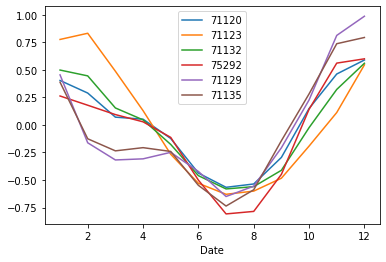

In [58]:
tst['1931':'1981'].groupby(tst['1931':'1981'].index.month).mean().plot()

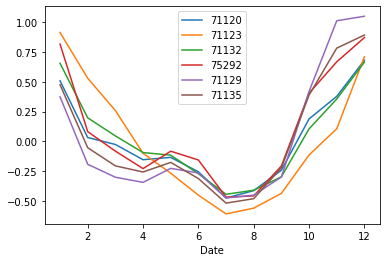

In [55]:
tst['1979':'2019'].groupby(tst['1979':'2019'].index.month).mean().plot()

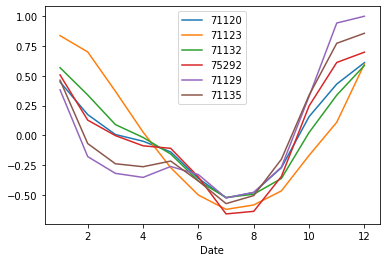

In [56]:
tst.groupby(tst.index.month).mean().plot()